In [1]:
!git clone https://github.com/Mohamed-Elkady-05/AutoVision-Perception
%cd AutoVision-Perception

Cloning into 'AutoVision-Perception'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 82 (delta 25), reused 70 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 2.99 MiB | 8.74 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/AutoVision-Perception


## Imports & Download

In [2]:
import kagglehub
import os

print("Downloading GTSRB Dataset...")
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

# Define the data path for the rest of the notebook
data_path = os.path.join(path, 'Train')
if not os.path.exists(data_path):
    data_path = os.path.join(path, 'train') # Fallback for lowercase

print(f"Dataset downloaded and the train folder located at: {data_path}")

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset downloaded and the train folder located at: /kaggle/input/gtsrb-german-traffic-sign/Train


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision import models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time

try:
    from CNN_model import TrafficSignCNN
    print("Successfully imported TrafficSignCNN from CNN_model.py")
except ImportError:
    print("ERROR: Could not find CNN_model.py. Please upload it to Colab.")

# Force PyTorch to use the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Successfully imported TrafficSignCNN from CNN_model.py
Using device: cuda


## Data Preparation

In [4]:
# 1. Define Data Augmentation & Normalization for Training
train_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(15),           # Augmentation: Slight rotations
    transforms.ColorJitter(brightness=0.2),  # Augmentation: Lighting variations
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))     # Standardize pixel values
])

test_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. Load the full dataset using the path from Cell 1
print(f"Loading images from {data_path}...")
full_dataset = datasets.ImageFolder(root=data_path, transform=train_transforms)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = test_transforms

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"Loaded {len(train_dataset)} training images and {len(val_dataset)} validation images.")

Loading images from /kaggle/input/gtsrb-german-traffic-sign/Train...
Loaded 31367 training images and 7842 validation images.


## Training

In [11]:
# TRAINING
model = TrafficSignCNN(num_classes=43).to(device)
criterion = nn.CrossEntropyLoss()

# Improvement: L2 Regularization (weight_decay) added to the Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 10
print(f"Starting Training for {epochs} epochs on {device}...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

print("Training Complete!")

Starting Training for 10 epochs on cuda...
Epoch [1/10] - Loss: 1.9942
Epoch [2/10] - Loss: 0.5117
Epoch [3/10] - Loss: 0.2169
Epoch [4/10] - Loss: 0.1283
Epoch [5/10] - Loss: 0.0895
Epoch [6/10] - Loss: 0.0670
Epoch [7/10] - Loss: 0.0558
Epoch [8/10] - Loss: 0.0522
Epoch [9/10] - Loss: 0.0452
Epoch [10/10] - Loss: 0.0360
Training Complete!


## Evaluation

Evaluating model on validation set...
\n Validation Accuracy: 99.46%


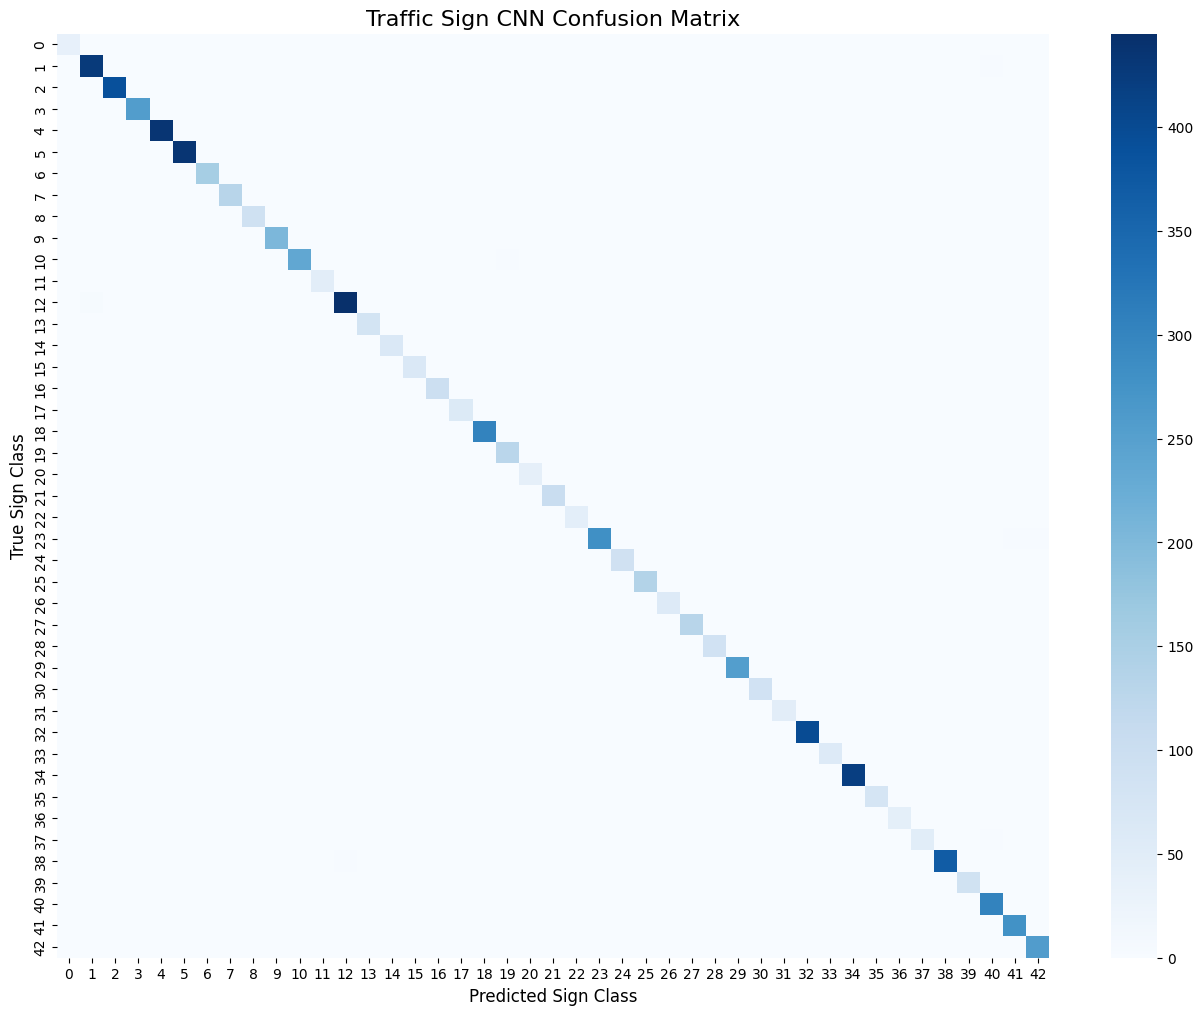

In [12]:
model.eval()
all_preds = []
all_labels = []

print("Evaluating model on validation set...")
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"\\n Validation Accuracy: {acc * 100:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
plt.title("Traffic Sign CNN Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Sign Class", fontsize=12)
plt.ylabel("True Sign Class", fontsize=12)
plt.show()

# Transfer Learning

## helper functions

In [6]:
import gc

NUM_CLASSES = 43
WARMUP_EPOCHS = 5
FINETUNE_EPOCHS = 10

results = {
    'MobileNetV2': {'pre_acc': 0, 'final_acc': 0, 'val_loss_history': []},
    'VGG16': {'pre_acc': 0, 'final_acc': 0, 'val_loss_history': []}
}

def evaluate_model(model, dataloader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, (correct / total) * 100

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, phase_name):
    print(f"\n--- Starting {phase_name} ({epochs} Epochs) ---")
    val_loss_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # Training pass
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total * 100

        # Validation pass to track history
        val_loss, val_acc = evaluate_model(model, val_loader)
        val_loss_history.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return val_loss_history

def run_experiment(model_name, model, head_index, num_classes):
    print(f"\n{'='*40}\nEXPERIMENT: {model_name}\n{'='*40}")

    # Freeze Base
    for param in model.parameters():
        param.requires_grad = False

    # Replace Head
    in_features = model.classifier[head_index].in_features
    model.classifier[head_index] = nn.Linear(in_features, num_classes)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    # Warm-up
    optimizer_warmup = optim.Adam(model.classifier.parameters(), lr=0.001)
    warmup_losses = train_model(model, train_loader, val_loader, criterion, optimizer_warmup, WARMUP_EPOCHS, f"{model_name} Warm-up")

    # Record Baseline Accuracy
    _, pre_acc = evaluate_model(model, val_loader)
    results[model_name]['pre_acc'] = pre_acc
    print(f">>> {model_name} Baseline Validation before Fine-tuning: {pre_acc:.2f}%")

    # Fine-tune
    for param in model.parameters():
        param.requires_grad = True
    optimizer_finetune = optim.Adam(model.parameters(), lr=1e-5)
    finetune_losses = train_model(model, train_loader, val_loader, criterion, optimizer_finetune, FINETUNE_EPOCHS, f"{model_name} Fine-Tuning")

    # Record Final Accuracy and History
    _, final_acc = evaluate_model(model, val_loader)
    results[model_name]['final_acc'] = final_acc
    results[model_name]['val_loss_history'] = warmup_losses + finetune_losses
    print(f">>> {model_name} Final Validation after Fine-tuning: {final_acc:.2f}%\n")

    # Clear Memory
    del model
    gc.collect()
    torch.cuda.empty_cache()

## training / fine-tuning

In [7]:
# Run MobileNetV2
model_mobile = models.mobilenet_v2(weights='DEFAULT')
run_experiment('MobileNetV2', model_mobile, head_index=1, num_classes=NUM_CLASSES)

# Run VGG16
model_vgg = models.vgg16(weights='DEFAULT')
run_experiment('VGG16', model_vgg, head_index=6, num_classes=NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 120MB/s]



EXPERIMENT: MobileNetV2

--- Starting MobileNetV2 Warm-up (5 Epochs) ---
Epoch [1/5] | Train Acc: 27.86% | Val Loss: 2.2358 | Val Acc: 39.85%
Epoch [2/5] | Train Acc: 36.28% | Val Loss: 2.0585 | Val Acc: 43.32%
Epoch [3/5] | Train Acc: 38.34% | Val Loss: 2.0001 | Val Acc: 44.59%
Epoch [4/5] | Train Acc: 39.34% | Val Loss: 2.0367 | Val Acc: 43.80%
Epoch [5/5] | Train Acc: 39.54% | Val Loss: 1.9619 | Val Acc: 45.69%
>>> MobileNetV2 Baseline Validation before Fine-tuning: 45.69%

--- Starting MobileNetV2 Fine-Tuning (10 Epochs) ---
Epoch [1/10] | Train Acc: 43.54% | Val Loss: 1.7556 | Val Acc: 50.56%
Epoch [2/10] | Train Acc: 47.07% | Val Loss: 1.6262 | Val Acc: 53.46%
Epoch [3/10] | Train Acc: 50.31% | Val Loss: 1.5666 | Val Acc: 54.59%
Epoch [4/10] | Train Acc: 53.15% | Val Loss: 1.4955 | Val Acc: 56.59%
Epoch [5/10] | Train Acc: 55.19% | Val Loss: 1.3666 | Val Acc: 59.17%
Epoch [6/10] | Train Acc: 56.96% | Val Loss: 1.3234 | Val Acc: 60.62%
Epoch [7/10] | Train Acc: 58.46% | Val Loss:

100%|██████████| 528M/528M [00:08<00:00, 65.8MB/s]



EXPERIMENT: VGG16

--- Starting VGG16 Warm-up (5 Epochs) ---
Epoch [1/5] | Train Acc: 46.92% | Val Loss: 1.1446 | Val Acc: 63.80%
Epoch [2/5] | Train Acc: 56.68% | Val Loss: 0.9847 | Val Acc: 67.89%
Epoch [3/5] | Train Acc: 59.09% | Val Loss: 0.9194 | Val Acc: 70.10%
Epoch [4/5] | Train Acc: 60.65% | Val Loss: 0.9138 | Val Acc: 70.42%
Epoch [5/5] | Train Acc: 61.09% | Val Loss: 0.8478 | Val Acc: 72.25%
>>> VGG16 Baseline Validation before Fine-tuning: 72.25%

--- Starting VGG16 Fine-Tuning (10 Epochs) ---
Epoch [1/10] | Train Acc: 74.20% | Val Loss: 0.3926 | Val Acc: 87.50%
Epoch [2/10] | Train Acc: 85.89% | Val Loss: 0.2316 | Val Acc: 93.00%
Epoch [3/10] | Train Acc: 91.88% | Val Loss: 0.1446 | Val Acc: 95.70%
Epoch [4/10] | Train Acc: 94.99% | Val Loss: 0.1090 | Val Acc: 96.60%
Epoch [5/10] | Train Acc: 96.54% | Val Loss: 0.0853 | Val Acc: 97.50%
Epoch [6/10] | Train Acc: 97.72% | Val Loss: 0.0650 | Val Acc: 98.10%
Epoch [7/10] | Train Acc: 98.27% | Val Loss: 0.0677 | Val Acc: 97.99

## Graphs

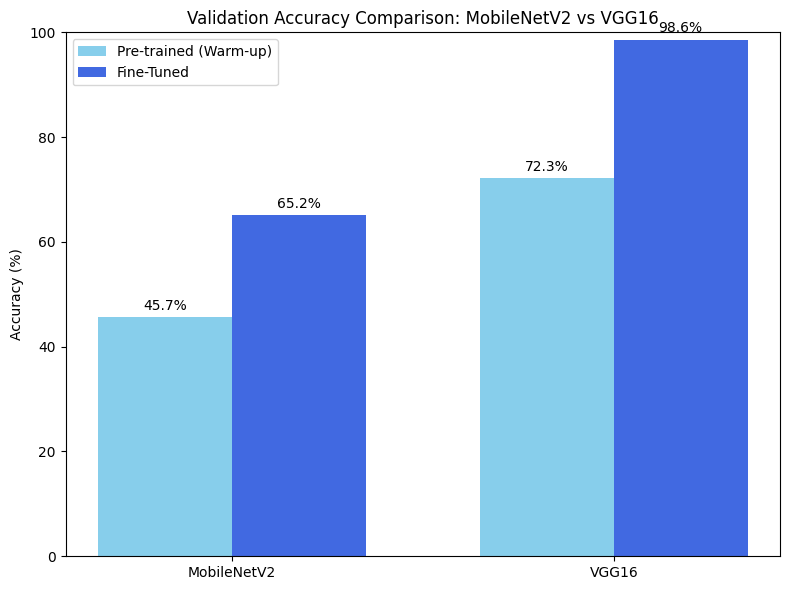

In [9]:
model_names = ['MobileNetV2', 'VGG16']
pre_accs = [results['MobileNetV2']['pre_acc'], results['VGG16']['pre_acc']]
final_accs = [results['MobileNetV2']['final_acc'], results['VGG16']['final_acc']]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, pre_accs, width, label='Pre-trained (Warm-up)', color='skyblue')
rects2 = ax.bar(x + width/2, final_accs, width, label='Fine-Tuned', color='royalblue')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Validation Accuracy Comparison: MobileNetV2 vs VGG16')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 100)
ax.legend()

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

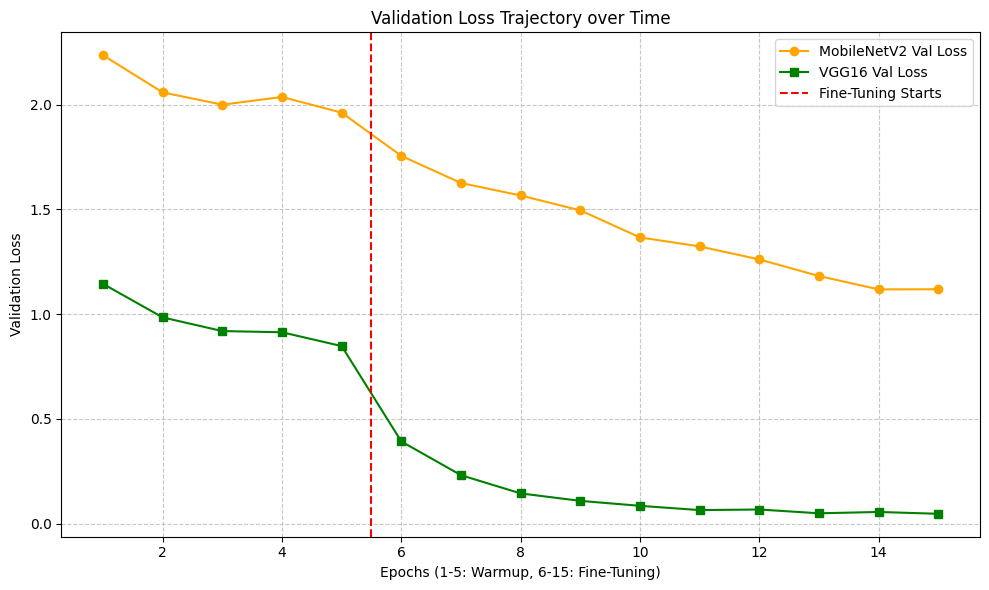

In [10]:
total_epochs = WARMUP_EPOCHS + FINETUNE_EPOCHS
epochs_axis = np.arange(1, total_epochs + 1)

mobile_loss = results['MobileNetV2']['val_loss_history']
vgg_loss = results['VGG16']['val_loss_history']

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_axis, mobile_loss, marker='o', linestyle='-', color='orange', label='MobileNetV2 Val Loss')
ax.plot(epochs_axis, vgg_loss, marker='s', linestyle='-', color='green', label='VGG16 Val Loss')

ax.axvline(x=WARMUP_EPOCHS + 0.5, color='red', linestyle='--', label='Fine-Tuning Starts')

ax.set_xlabel(f'Epochs (1-{WARMUP_EPOCHS}: Warmup, {WARMUP_EPOCHS+1}-{total_epochs}: Fine-Tuning)')
ax.set_ylabel('Validation Loss')
ax.set_title('Validation Loss Trajectory over Time')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()